<a href="https://colab.research.google.com/github/sofialuiza15/projetos-ml/blob/main/ProjetoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Projeto final

link relatório: https://docs.google.com/document/d/1VSu7gnrGYSGNLe-gsJ8GQXTauzdQGMqELejaaG8wvM0/edit?usp=sharing

In [ ]:
!pip uninstall -y transformers accelerate granite-tsfm torch torchvision

Found existing installation: transformers 4.56.0
Uninstalling transformers-4.56.0:
  Successfully uninstalled transformers-4.56.0
Found existing installation: accelerate 1.12.0
Uninstalling accelerate-1.12.0:
  Successfully uninstalled accelerate-1.12.0
Found existing installation: granite-tsfm 0.3.3
Uninstalling granite-tsfm-0.3.3:
  Successfully uninstalled granite-tsfm-0.3.3
Found existing installation: torch 2.8.0
Uninstalling torch-2.8.0:
  Successfully uninstalled torch-2.8.0


In [ ]:
!pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git"

  Cloning https://github.com/ibm-granite/granite-tsfm.git to /tmp/pip-install-n_rstk5p/granite-tsfm_dd077b8107274cfcbfc9b82b5c623a21
  Running command git clone --filter=blob:none --quiet https://github.com/ibm-granite/granite-tsfm.git /tmp/pip-install-n_rstk5p/granite-tsfm_dd077b8107274cfcbfc9b82b5c623a21
  Resolved https://github.com/ibm-granite/granite-tsfm.git to commit 9f4d052058997741f23c9c9a6da7c422e5ce2d8a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached transformers-4.56.0-py3-none-any.whl.metadata (40 kB)
  Using cached torch-2.8.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached accelerate-1.12.0-py3-none-any.whl.metadata (19 kB)
Using cached transformers-4.56.0-py3-none-any.whl (11.6 MB)
Using cached torch-2.8.0-cp312-cp312-manylinux_2_28_x86_64.whl (887.9 MB)
Using cached accelerate-1.12.0-py3-none-any.whl (380 kB)
  Created wheel for granite-tsfm: file

In [ ]:
!pip install sktime

Importando Bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch

from transformers import(
    EarlyStoppingCallback,
    PatchTSMixerConfig,
    PatchTSMixerForPrediction,
    Trainer,
    TrainingArguments,
)

from sktime.datasets import load_forecastingdata
from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.util import select_by_index
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler

from sktime.utils.plotting import plot_series

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


DataSet escolhido: solar_weekly_dataset, representa a medição de irradiação solar semanal em diferentes pontos do estado do Alabama, nos EUA.

In [ ]:
data, meta = load_forecastingdata(name="solar_weekly_dataset")

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df_completo = data.reset_index()

print(df_completo)

     index series_name start_timestamp                                       series_value
0        0          T1      2006-01-01  [8946.9, 10540.6, 8865.65, 10986.9, 8987.1, 12...
1        1          T2      2006-01-01  [4811.25, 4609.2, 3543.5, 4960.55, 4652.2, 634...
2        2          T3      2006-01-01  [3639.9, 4016.05, 3708.3, 4204.85, 4432.55, 42...
3        3          T4      2006-01-01  [4219.2, 4765.4, 3395.6, 4883.65, 4416.25, 558...
4        4          T5      2006-01-01  [8011.05, 7764.95, 6344.8, 9538.9, 8780.8, 110...
5        5          T6      2006-01-01  [13215.65, 13978.55, 10779.1, 15410.5, 12631.3...
6        6          T7      2006-01-01  [4057.4, 4524.95, 3980.35, 4839.5, 4020.55, 52...
7        7          T8      2006-01-01  [3461.7, 3739.05, 3683.05, 4566.2, 3930.9, 455...
8        8          T9      2006-01-01  [3887.9, 4700.4, 3643.3, 5056.0, 4421.3, 5420....
9        9         T10      2006-01-01  [3336.5, 3335.95, 3694.1, 4492.4, 4146.1, 4638...
10      10

Formatando o dataset

In [ ]:
# deixando no formato longo (o modelo lê ele assim): | series_name | timestamp | value |
linhas = []

for i in range(len(data)):
    serie = data.loc[i, 'series_name']
    dataInicio = pd.to_datetime(data.loc[i, 'start_timestamp'])
    valores = data.loc[i, 'series_value']

    datas = pd.date_range(start=dataInicio, periods=len(valores), freq='W')

    temp = pd.DataFrame({
        'series_name': serie,
        'timestamp': datas,
        'value': valores
    })

    linhas.append(temp)

dfLongo = pd.concat(linhas, ignore_index=True)

print(dfLongo.groupby("series_name").size().describe())


count    137.0
mean      52.0
std        0.0
min       52.0
25%       52.0
50%       52.0
75%       52.0
max       52.0
dtype: float64


Plotagem do gráfico com todas as séries

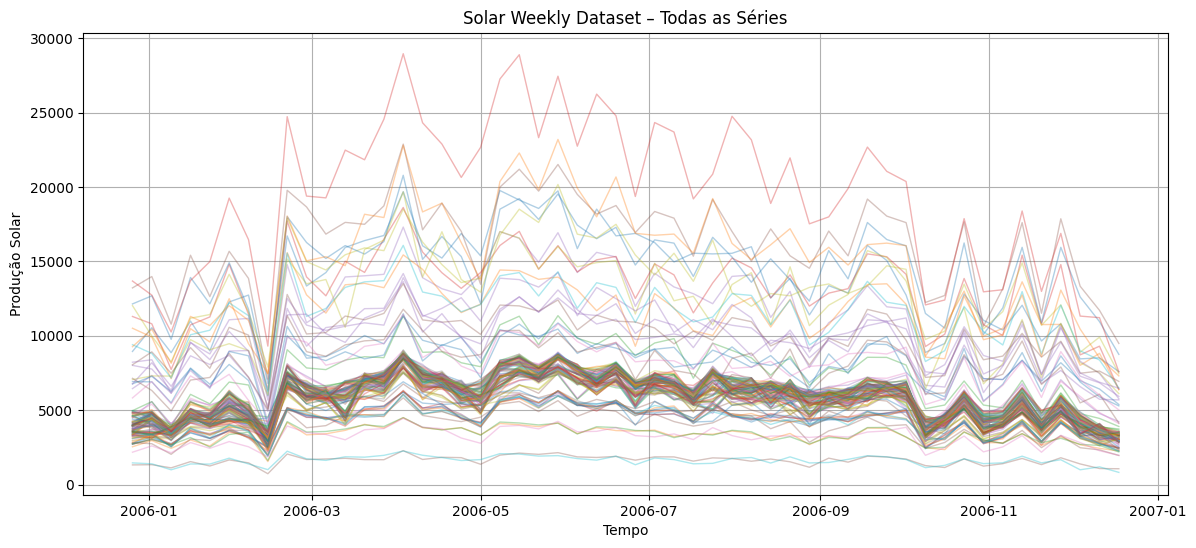

In [ ]:
plt.figure(figsize=(14, 6))

for _, linha in data.iterrows():
    valores = np.asarray(linha['series_value'], dtype=float)

    inicio = pd.Period(linha['start_timestamp'], freq='W')
    index = pd.period_range(start=inicio, periods=len(valores), freq='W')

    serie = pd.Series(valores, index=index)

    serie.index = serie.index.to_timestamp()

    plt.plot(serie, alpha=0.35, linewidth=1)

plt.title('Solar Weekly Dataset – Todas as Séries')
plt.xlabel('Tempo')
plt.ylabel('Produção Solar')
plt.grid(True)
plt.show()

Série escolhida T70

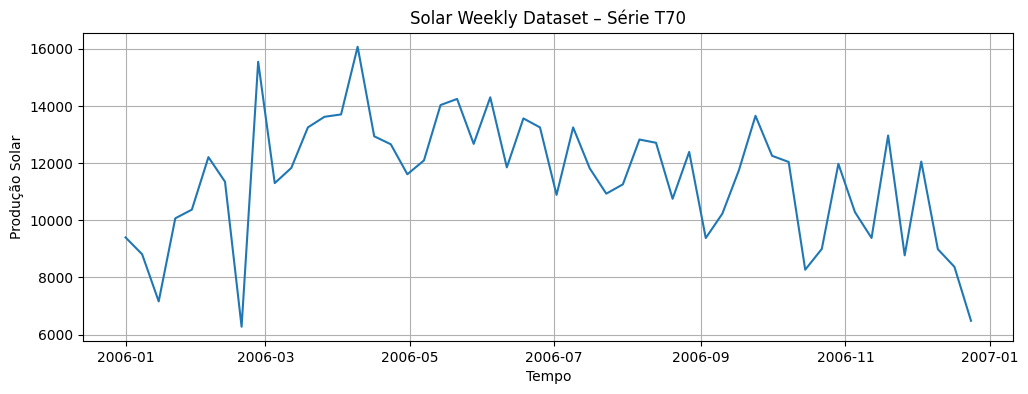

In [ ]:
serie = data.loc[data['series_name'] == 'T70'].iloc[0]
valores = np.asarray(serie['series_value'], dtype=float)

datas = pd.date_range(
    start = linha['start_timestamp'],
    periods = len(valores),
    freq = 'W'
)

plt.figure(figsize=(12, 4))
plt.plot(datas, valores)
plt.title('Solar Weekly Dataset – Série T70')
plt.xlabel('Tempo')
plt.ylabel('Produção Solar')
plt.grid(True)
plt.show()

Extraindo a série temporal alvo

In [ ]:
serieAlvo = data.loc[data['series_name'] == 'T70'].iloc[0]
valoresT70 = serieAlvo['series_value']

Aqui alteramos valores da T70 para o formato numérico e pegamos, não os valores, mas a tendência da série temporal, o padrão de crescimento e ocilações.

In [ ]:
def series_signature(series):
    y = np.asarray(series, dtype=float)

    y = StandardScaler().fit_transform(
        y.reshape(-1, 1)
    ).ravel()

    return np.diff(y)

In [ ]:
target_sig = series_signature(valoresT70)

Aqui ocorre a mesma lógica da série anterior. Além disso, evita o vazamento de informação relacionada à t70. O cut dessa primeira linha garante que nenhuma informação do futuro entre na assinatura.

In [ ]:
def series_signaturecorte(series, cut):
    y = np.asarray(series[:cut], dtype=float)

    scaler = StandardScaler()
    y = scaler.fit_transform(y.reshape(-1,1)).ravel()

    return np.diff(y)


In [ ]:
cut = int(0.8 * len(valoresT70))  # ou o mesmo t_train_end do modelo
target_sig = series_signaturecorte(valoresT70, cut)

Correlação cruzada atraso

In [ ]:
def max_lagged_corr(x, y, max_lag=30):
    x = np.diff(x)
    y = np.diff(y)

    L = min(len(x), len(y))
    x = x[:L]
    y = y[:L]

    best = 0

    for k in range(1, max_lag + 1):
        if k >= L:
            break

        r = np.corrcoef(x[:-k], y[k:])[0, 1]
        if np.isnan(r):
            continue

        best = max(best, abs(r))

    return best


In [ ]:
scores = []

for _, row in data.iterrows():
    name = row["series_name"]
    if name == 'T70':
        continue

    sig = series_signaturecorte(row["series_value"], cut)

    score = max_lagged_corr(sig, target_sig, max_lag=30)

    scores.append((name, score))

In [ ]:
scores = sorted(scores, key=lambda x: x[1], reverse=True)
top5 = scores[:5]

top5

[('T104', np.float64(0.8480054757576307)),
 ('T40', np.float64(0.8421371501507086)),
 ('T69', np.float64(0.84066941019844)),
 ('T20', np.float64(0.8321779282277237)),
 ('T30', np.float64(0.817951755701492))]

Gráfico séries com maior correlação

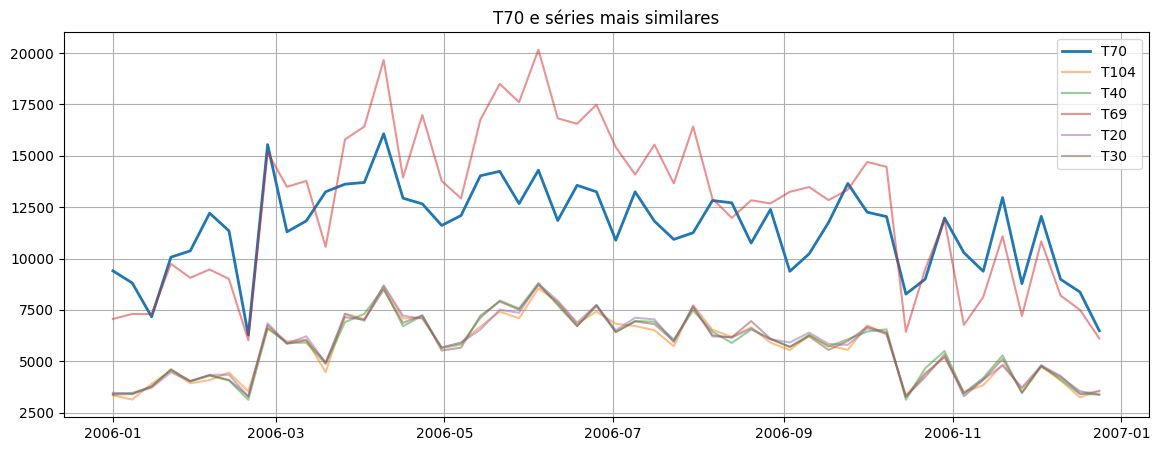

In [ ]:
plt.figure(figsize=(14, 5))

dates = pd.date_range(
    start=serieAlvo["start_timestamp"],
    periods=len(valoresT70),
    freq="W"
)

plt.plot(dates, valoresT70, label="T70", linewidth=2)

for name, _ in top5:
    row = data[data["series_name"] == name].iloc[0]
    values = np.asarray(row["series_value"], dtype=float)

    plt.plot(dates, values, alpha=0.5, label=name)

plt.legend()
plt.title("T70 e séries mais similares")
plt.grid(True)
plt.show()

Analisando cada série individualmente com valores não normalizados

In [ ]:
# função auxiliar para plotar os gráficos em comparação com a série T70
def comparacaoSemEscala(nomeserie, data, serieAlvo='T70'):
    t = data[data["series_name"] == serieAlvo].iloc[0]
    s = data[data["series_name"] == nomeserie].iloc[0]

    y_t = np.asarray(t["series_value"], dtype=float)
    y_s = np.asarray(s["series_value"], dtype=float)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    axs[0].plot(y_t, linewidth=2)
    axs[0].set_title(f'{serieAlvo} (escala original)')
    axs[0].grid(True)

    axs[1].plot(y_s, linewidth=2)
    axs[1].set_title(f'{nomeserie} (escala original)')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# função auxiliar para plotar os gráficos na mesma escala da série T70
def comparacaoNaEscalaT70(serie, data, ymin, ymax, serieAlvo="T70"):
    row_t = data[data["series_name"] == serieAlvo].iloc[0]
    row_s = data[data["series_name"] == serie].iloc[0]

    y_t = np.asarray(row_t["series_value"], dtype=float)
    y_s = np.asarray(row_s["series_value"], dtype=float)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    axs[0].plot(y_t, linewidth=2)
    axs[0].set_title(f'{serieAlvo} (escala  da T70)')
    axs[0].set_ylim(ymin, ymax)
    axs[0].grid(True)

    axs[1].plot(y_s, linewidth=2)
    axs[1].set_title(f'{serie} (escala  da T70)')
    axs[1].set_ylim(ymin, ymax)
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# definindo a escala padrão
row_t70 = data[data["series_name"] == "T70"].iloc[0]
y_t70 = np.asarray(row_t70["series_value"], dtype=float)

ymin, ymax = y_t70.min(), y_t70.max()
# deixa o espaço um pouco maior para vizualizar
pad = 0.1 * (ymax - ymin)
ymin -= pad
ymax += pad

Série T40

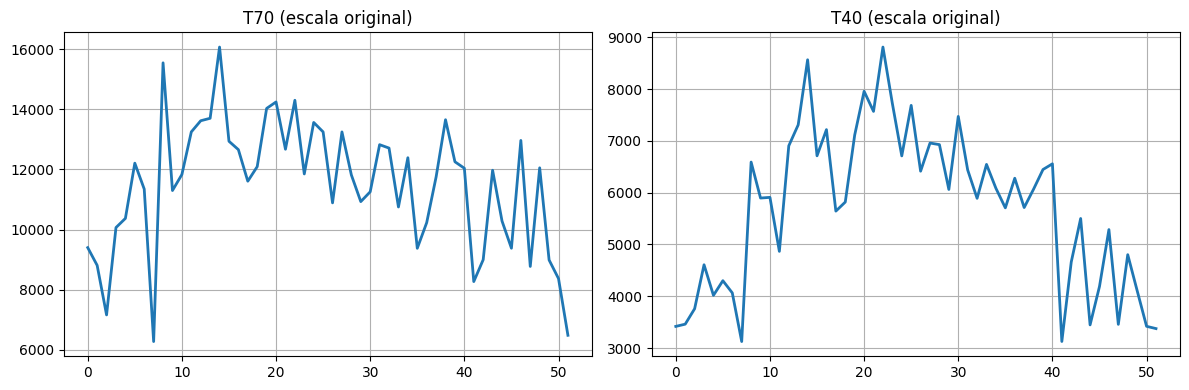

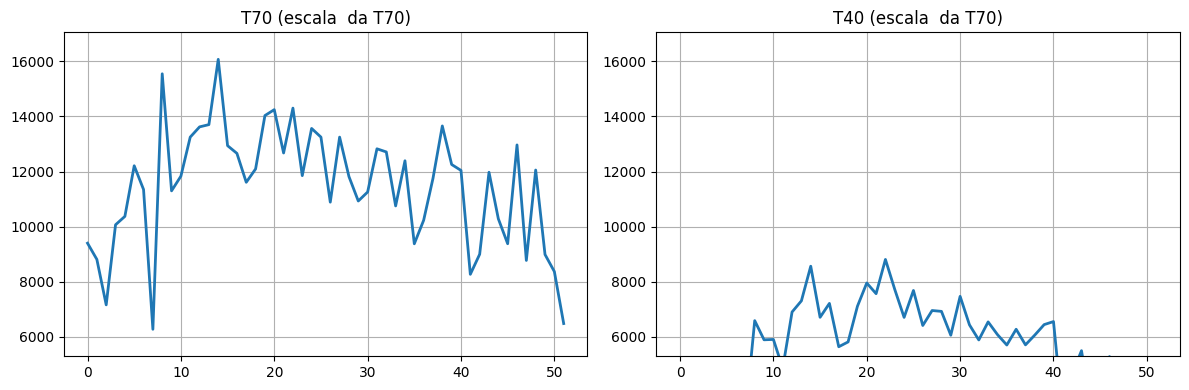

In [ ]:
comparacaoSemEscala('T40',data)
comparacaoNaEscalaT70('T40', data, ymin, ymax)

Série T20

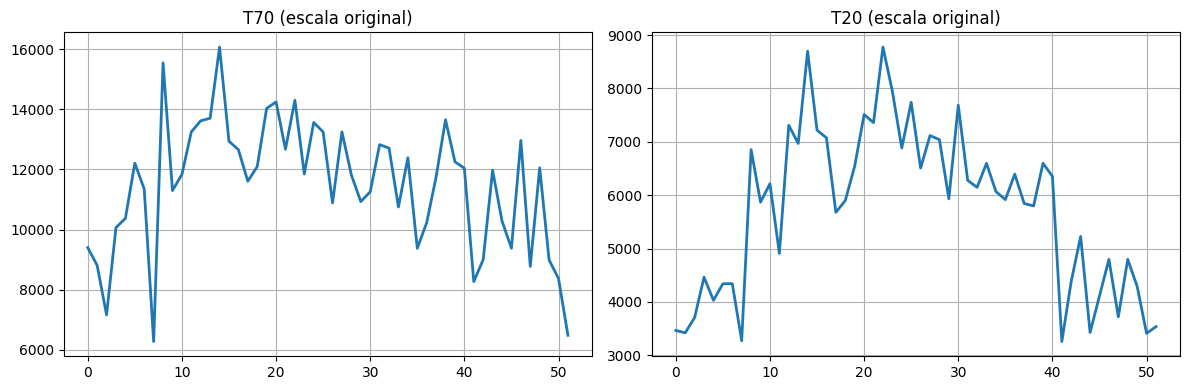

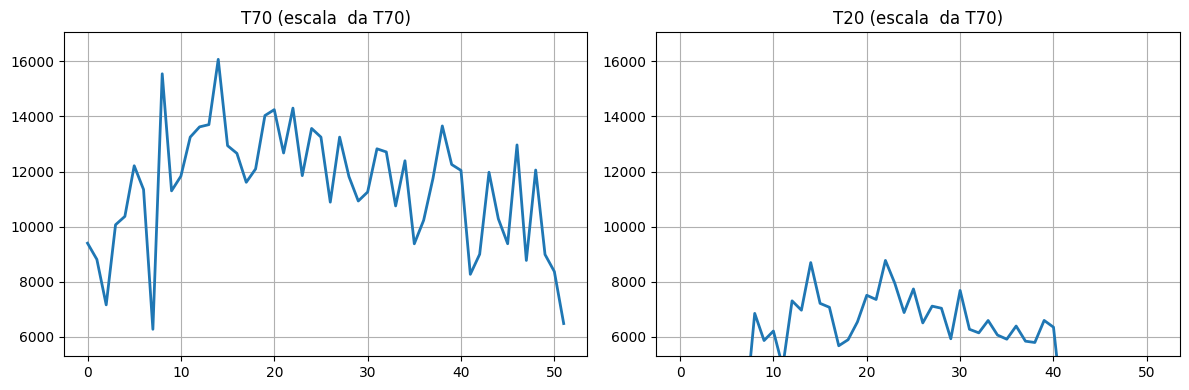

In [ ]:
comparacaoSemEscala('T20',data)
comparacaoNaEscalaT70('T20', data, ymin, ymax)

Série T69

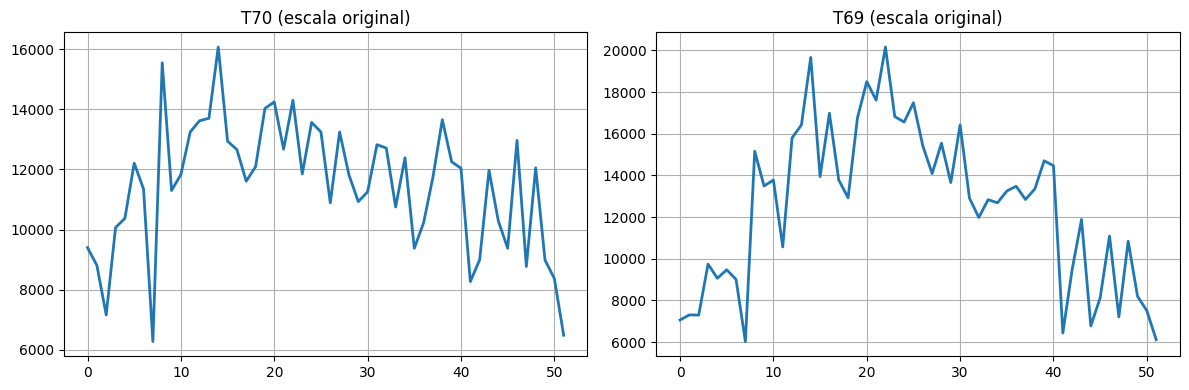

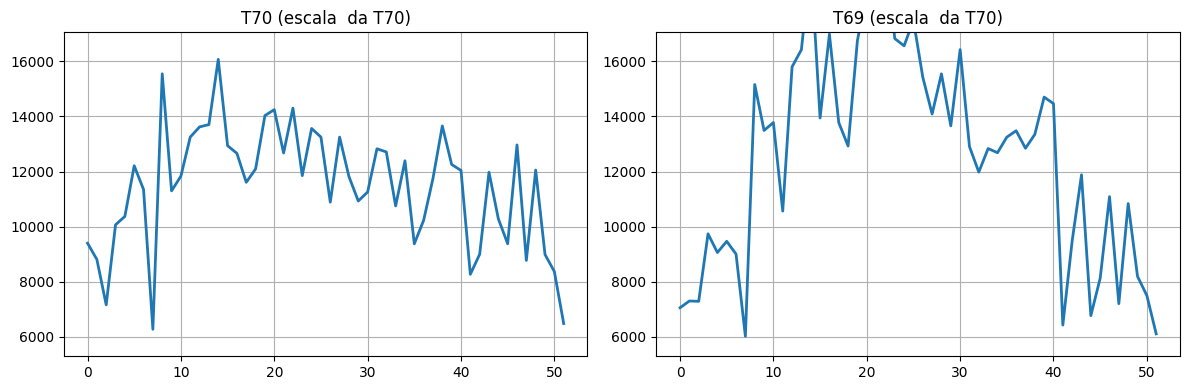

In [ ]:
comparacaoSemEscala('T69',data)
comparacaoNaEscalaT70('T69', data, ymin, ymax)

Série T40

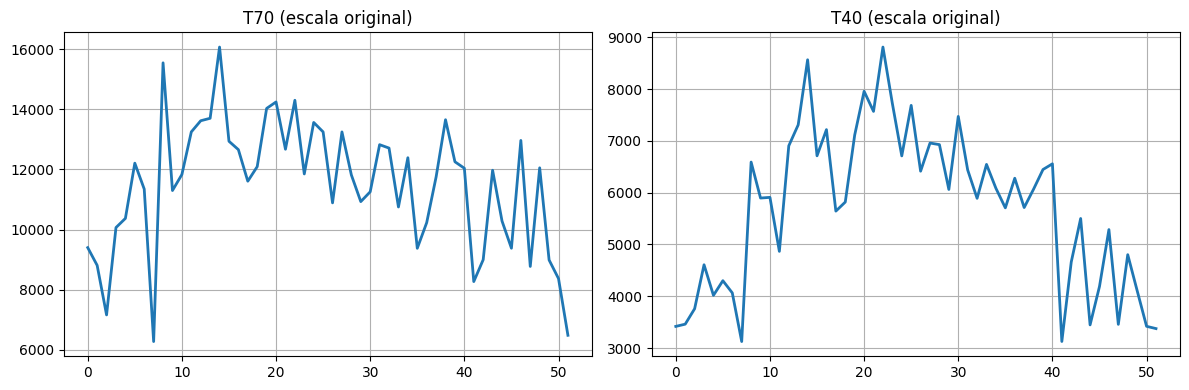

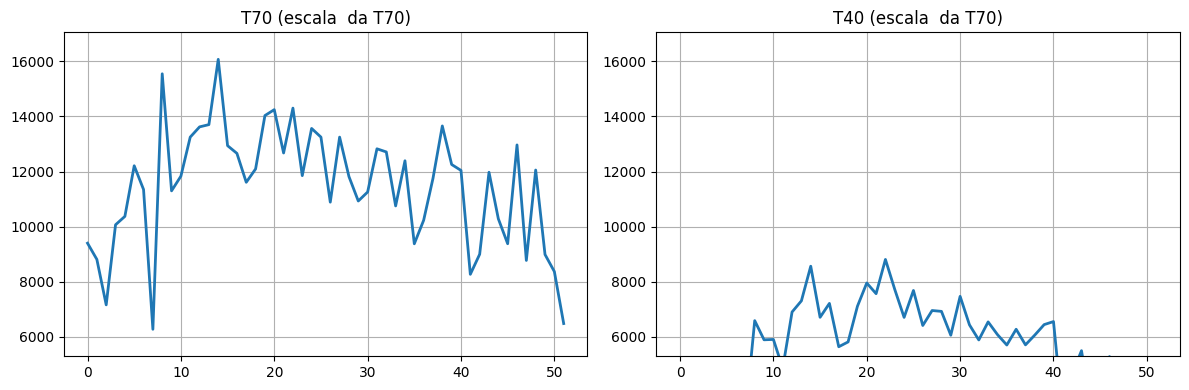

In [ ]:
comparacaoSemEscala('T40',data)
comparacaoNaEscalaT70('T40', data, ymin, ymax)

Série T104

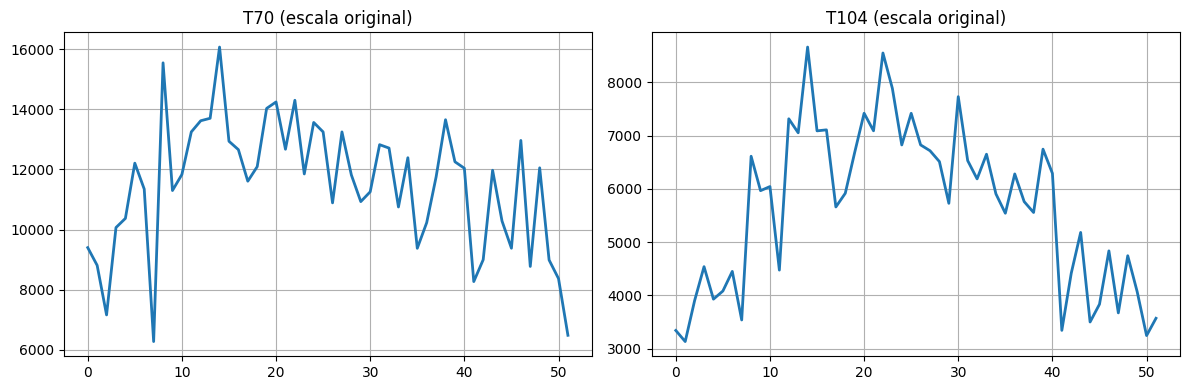

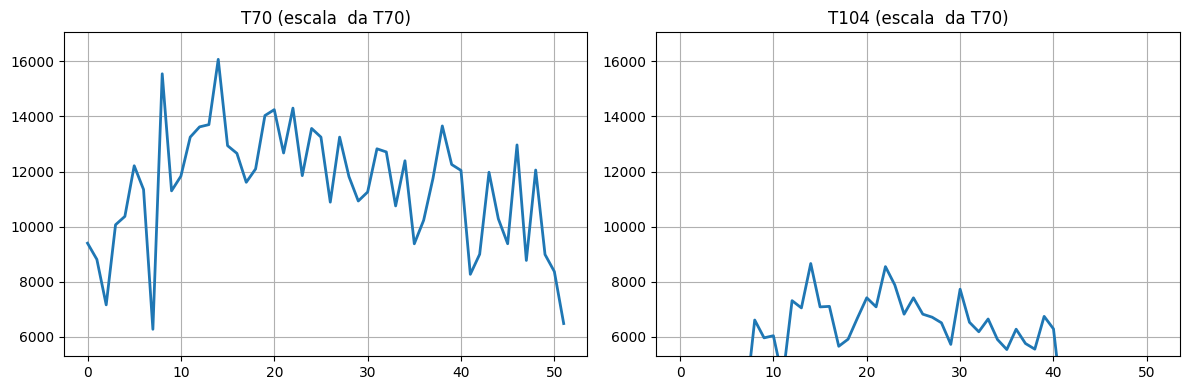

In [ ]:
comparacaoSemEscala('T104',data)
comparacaoNaEscalaT70('T104', data, ymin, ymax)


Gráfico com os dados normalizados para mostrar o crescimento parecido que eles tem

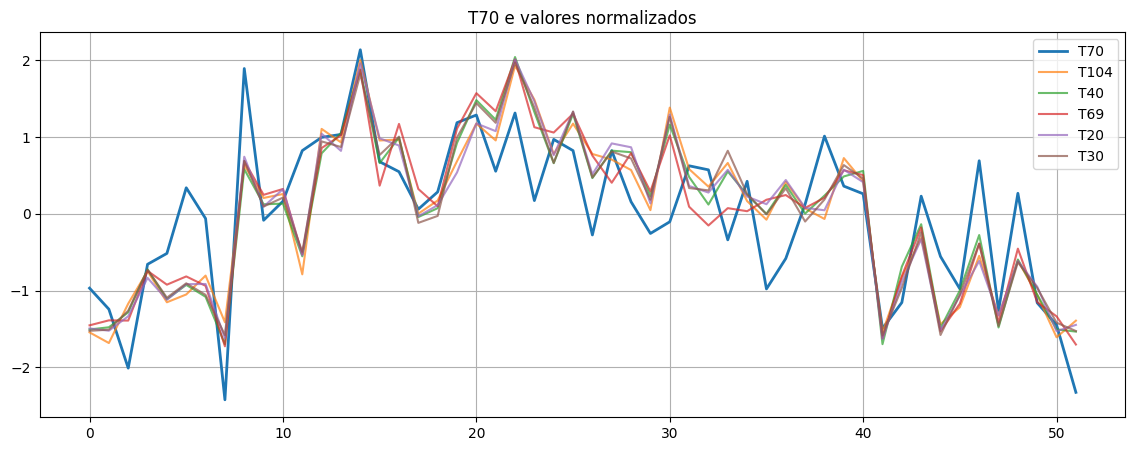

In [ ]:
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(14, 5))

def norm(x):
    return StandardScaler().fit_transform(
        x.reshape(-1, 1)
    ).ravel()

# T70
plt.plot(norm(np.asarray(valoresT70)), label="T70", linewidth=2)

# auxiliares
for name, _ in top5:
    row = data[data["series_name"] == name].iloc[0]
    values = np.asarray(row["series_value"], dtype=float)
    plt.plot(norm(values), alpha=0.7, label=name)

plt.legend()
plt.title("T70 e valores normalizados")
plt.grid(True)
plt.show()


Separação das series a serem utilizadas, aparentemente, a t70 estava entrando tambem, a separação nao estava funcionando

In [ ]:
serieAlvo = 'T70'
seriesEscolhidas = ['T104','T40', 'T69', 'T30','T20']

series_todas = []
series_5 = []

for _, linha in data.iterrows():
    nome = linha["series_name"]
    valores = linha["series_value"]

    if nome == serieAlvo:
        continue

    series_todas.append(valores)

    if nome in seriesEscolhidas:
        series_5.append(valores)

In [ ]:
dfLongo.groupby("series_name").size().describe()

,0
count,137.0
mean,52.0
std,0.0
min,52.0
25%,52.0
50%,52.0
75%,52.0
max,52.0


In [ ]:
contexto = 24   # 6 meses
fh = 12  # 3 meses

In [ ]:
class DatasetPatchTS(Dataset):
    def __init__(self, series_list, ctx, fh, split="train", split_ratio=0.85):
        self.samples = []

        for values in series_list:
            y = np.asarray(values, dtype=float)

            scaler = StandardScaler()
            y = scaler.fit_transform(y.reshape(-1,1)).ravel()

            cut = int(split_ratio * len(y))

            if split == "train":
                y_use = y[:cut]
            else:
                y_use = y[cut - ctx - fh + 1 :]

            for i in range(len(y_use) - ctx - fh + 1):
                past = y_use[i:i+ctx]
                future = y_use[i+ctx:i+ctx+fh]

                self.samples.append({
                    "past_values": torch.tensor(
                        past, dtype=torch.float32
                    ).unsqueeze(-1),
                    "future_values": torch.tensor(
                        future, dtype=torch.float32
                    ).unsqueeze(-1)
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

Função auxiliar para rodar o treinamento

In [ ]:
def rodarTreinamento(series_list, tipoTreino):
    print(f"\nTreino: {tipoTreino}")


    ds_train = DatasetPatchTS(series_list, contexto, fh, split="train")
    ds_val   = DatasetPatchTS(series_list, contexto, fh, split="val")

    print(f'Janelas treino: {len(ds_train)} | validação: {len(ds_val)}')

    config = PatchTSMixerConfig(
        context_length=contexto,
        prediction_length=fh,
        input_size=1,
        num_input_channels=1,
        d_model=64,
        num_layers=3,
        dropout=0.1,
        mode="common_channel"
    )

    model = PatchTSMixerForPrediction(config)

    trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir=f"./out_{tipoTreino}",
        overwrite_output_dir=True,

        num_train_epochs=150,
        learning_rate=1e-4,

        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,

        eval_strategy="steps",
        eval_steps=10,

        save_strategy="no",
        metric_for_best_model="eval_loss",

        report_to="none",
        label_names=["future_values"]
    ),
    train_dataset=ds_train,
    eval_dataset=ds_val,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=10
        )
    ]
)

    trainer.train()
    return model

Rodando treinamento

In [ ]:
# treino 1: Usando séries escolhidas
modelo_5 = rodarTreinamento(series_5, "5_melhores")

# treino 2: Usando todas as séries
modelo_all = rodarTreinamento(series_todas, "Todas_series")


Treino: 5_melhores
Janelas treino: 45 | validação: 40


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss
10,No log,1.979902
20,No log,1.954287
30,No log,1.929040
40,No log,1.904904
50,No log,1.882270
60,No log,1.860231
70,No log,1.840634
80,No log,1.822604
90,No log,1.805784
100,No log,1.790372



Treino: Todas_series
Janelas treino: 1224 | validação: 1088


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss
10,No log,1.976920
20,No log,1.947262
30,No log,1.916875
40,No log,1.887694
50,No log,1.859536
60,No log,1.830332
70,No log,1.803053
80,No log,1.778916
90,No log,1.755134
100,No log,1.732446


In [ ]:
def prever_T70(modelo, valores):
    y = np.asarray(valores, dtype=float)

    scaler = StandardScaler()
    y_norm = scaler.fit_transform(y.reshape(-1,1)).ravel()

    past = torch.tensor(
    y_norm[-contexto:], dtype=torch.float32
).unsqueeze(0).unsqueeze(-1).to(device)

    modelo.eval()
    with torch.no_grad():
        pred = modelo(past_values=past).prediction_outputs

    pred = pred.squeeze().cpu().numpy()
    return scaler.inverse_transform(pred.reshape(-1,1)).ravel()

Função de avaliação dos resultados do modelo:

In [ ]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred))


In [ ]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

Plotando gráfico

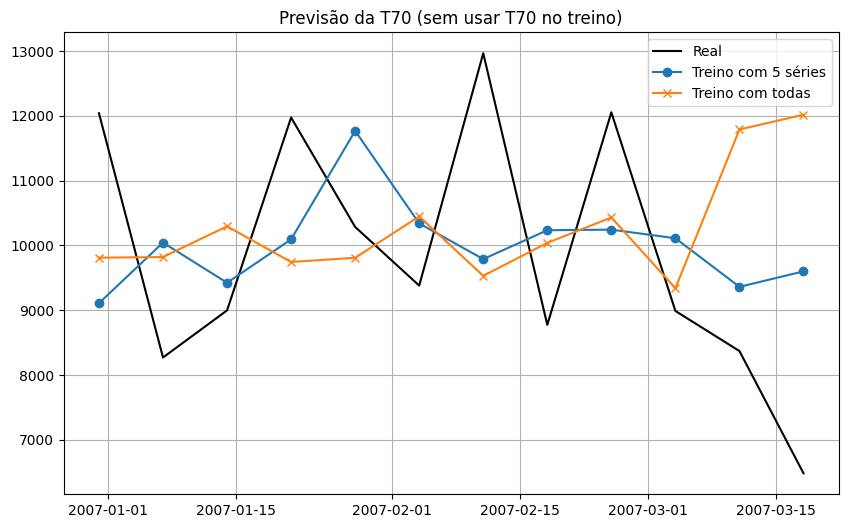

In [ ]:
y_real = valoresT70[-fh:]

pred_5 = prever_T70(modelo_5,valoresT70)
pred_all = prever_T70(modelo_all, valoresT70)

datas = pd.date_range(
    start=dfLongo["timestamp"].max(),
    periods=fh+1,
    freq="W"
)[1:]

plt.figure(figsize=(10,6))
plt.plot(datas, y_real, label="Real", color="black")
plt.plot(datas, pred_5, label="Treino com 5 séries", marker="o")
plt.plot(datas, pred_all, label="Treino com todas", marker="x")
plt.title(f"Previsão da {serieAlvo} (sem usar {serieAlvo} no treino)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_real = valoresT70[-fh:]

pred_5 = prever_T70(modelo_5, valoresT70)
pred_all = prever_T70(modelo_all, valoresT70)

mae_5 = mae(y_real, pred_5)
mae_all = mae(y_real, pred_all)

rmse_5 = rmse(y_real, pred_5)
rmse_all = rmse(y_real, pred_all)

print(f"MAE – Treino com 5 séries: {mae_5:.3f}")
print(f"MAE – Treino com todas as séries: {mae_all:.3f}")

print(f"\nRMSE – Treino com 5 séries: {rmse_5:.3f}")
print(f"RMSE – Treino com todas as séries: {rmse_all:.3f}")

MAE – Treino com 5 séries: 1972.623
MAE – Treino com todas as séries: 2039.513

RMSE – Treino com 5 séries: 2301.890
RMSE – Treino com todas as séries: 2480.779
